In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q monai nibabel wandb python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 31.6 MB/s eta 0:00:00


In [ ]:
# Import libraries

import os
import json
import time
import random

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader as TorchDataLoader

import monai
from monai.data import Dataset, DataLoader, decollate_batch
from monai.networks.nets import UNet
from monai.losses import DiceFocalLoss
from monai.metrics import DiceMetric
from monai.transforms import (
    LoadImaged,
    EnsureChannelFirstd,
    ConcatItemsd,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    AsDiscrete,
    Compose,
)
from monai.inferers import sliding_window_inference

import wandb
from dotenv import load_dotenv

load_dotenv()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"MONAI version: {monai.__version__}")
print(f"Using device: {device}")

MONAI version: 1.6.0
Using device: cuda


In [ ]:
# Config & Paths
# Project paths and settings

BASE_DIR = "/content/drive/MyDrive/brain-tumor-segmentation"

PATHS = {
    "training_dir": "/content/BraTS2020_TrainingData",
    "configs": os.path.join(BASE_DIR, "configs"),
    "models": os.path.join(BASE_DIR, "models", "baseline"),
    "figures": os.path.join(BASE_DIR, "results", "figures"),
    "metrics": os.path.join(BASE_DIR, "results", "metrics"),
}

for key in ["configs", "models", "figures", "metrics"]:
    os.makedirs(PATHS[key], exist_ok=True)

print("Paths configured:")
for name, path in PATHS.items():
    status = "OK" if os.path.exists(path) else "missing"
    print(f"  [{status}] {name:14s} -> {path}")

Paths configured:
  [missing] training_dir   -> /content/BraTS2020_TrainingData
  [OK] configs        -> /content/drive/MyDrive/brain-tumor-segmentation/configs
  [OK] models         -> /content/drive/MyDrive/brain-tumor-segmentation/models/baseline
  [OK] figures        -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures
  [OK] metrics        -> /content/drive/MyDrive/brain-tumor-segmentation/results/metrics


In [ ]:
import shutil
import os

DRIVE_DATA = os.path.join(
    BASE_DIR,
    "archive",
    "BraTS2020_TrainingData",
    "MICCAI_BraTS2020_TrainingData"
)

LOCAL_DATA = "/content/BraTS2020_TrainingData"

if os.path.exists(LOCAL_DATA):
    print("Local dataset already exists.")
else:
    print("Copying training dataset from Google Drive...")
    print("This may take a while the first time.")

    shutil.copytree(DRIVE_DATA, LOCAL_DATA)

    print("Dataset copy complete!")

print("Local dataset exists:", os.path.exists(LOCAL_DATA))
print("Patient folders:", len(os.listdir(LOCAL_DATA)))

Copying training dataset from Google Drive...
This may take a while the first time.
Dataset copy complete!
Local dataset exists: True
Patient folders: 371


In [ ]:
# Build the 3D U-Net model

model = UNet(
    spatial_dims=3,
    in_channels=4,       # 4 MRI modalities (T1, T1ce, T2, FLAIR)
    out_channels=4,      # 4 classes (background, NCR/NET, ED, ET)
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Model built: 3D U-Net")
print(f"Total parameters: {n_params:,}")

Model built: 3D U-Net
Total parameters: 4,811,129


In [ ]:
# Define loss function and label remapping
# BraTS labels are {0, 1, 2, 4} — we remap 4 -> 3 so classes are contiguous (0,1,2,3)

from monai.transforms import MapTransform

class RemapLabeld(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            d[key][d[key] == 4] = 3
        return d


# loss_function = DiceFocalLoss(
#     to_onehot_y=True,
#     softmax=True,
#     lambda_dice=0.5,
#     lambda_focal=0.5,
# )

loss_function = DiceFocalLoss(
    to_onehot_y=True,
    softmax=True,
    lambda_dice=0.5,
    lambda_focal=0.5,
    batch=True,        # pool TP/FP/FN across the batch before dividing,
                        # so a rare class present in only one patch isn't
                        # swamped by softmax leakage in a patch where it's absent
    smooth_nr=1.0,      # default 1e-5 is far smaller than the softmax leakage
    smooth_dr=1.0,      # across an 885k-voxel patch — this was the actual bug
)

print("Loss function: DiceFocalLoss (0.5 * Dice + 0.5 * Focal)")
print("Label remapping: 4 -> 3 (so classes are contiguous: 0=background, 1=NCR/NET, 2=ED, 3=ET)")

Loss function: DiceFocalLoss (0.5 * Dice + 0.5 * Focal)
Label remapping: 4 -> 3 (so classes are contiguous: 0=background, 1=NCR/NET, 2=ED, 3=ET)


In [ ]:
# Build training and validation data dictionaries

split_path = os.path.join(PATHS["configs"], "dataset_split.json")

with open(split_path, "r") as f:
    split_dict = json.load(f)

train_patients = split_dict["train"]
val_patients = split_dict["val"]

modalities = ["t1", "t1ce", "t2", "flair"]


def find_segmentation_file(patient_dir, pid):
    """
    Find the segmentation file for a patient.

    Normally BraTS uses:
        <patient_id>_seg.nii

    If a patient has a non-standard filename, look for the
    only NIfTI file containing 'seg' in its filename.
    """

    # Standard filename
    expected = os.path.join(patient_dir, f"{pid}_seg.nii")

    if os.path.exists(expected):
        return expected

    # Fallback for non-standard filenames
    candidates = [
        os.path.join(patient_dir, filename)
        for filename in os.listdir(patient_dir)
        if filename.lower().endswith((".nii", ".nii.gz"))
        and "seg" in filename.lower()
    ]

    if len(candidates) == 1:
        print(f"Using non-standard segmentation filename for {pid}:")
        print(f"  {os.path.basename(candidates[0])}")
        return candidates[0]

    if len(candidates) == 0:
        raise FileNotFoundError(
            f"No segmentation file found for patient {pid} "
            f"in {patient_dir}"
        )

    raise RuntimeError(
        f"Multiple segmentation files found for patient {pid}: "
        f"{candidates}"
    )


def build_data_dicts(patient_list, training_dir):
    data_dicts = []

    for pid in patient_list:
        patient_dir = os.path.join(training_dir, pid)

        entry = {
            mod: os.path.join(
                patient_dir,
                f"{pid}_{mod}.nii"
            )
            for mod in modalities
        }

        entry["label"] = find_segmentation_file(
            patient_dir,
            pid
        )

        entry["patient_id"] = pid

        data_dicts.append(entry)

    return data_dicts


train_dicts = build_data_dicts(
    train_patients,
    PATHS["training_dir"]
)

val_dicts = build_data_dicts(
    val_patients,
    PATHS["training_dir"]
)

patch_size = (96, 96, 96)

train_transforms = Compose([
    LoadImaged(keys=modalities + ["label"]),
    EnsureChannelFirstd(keys=modalities + ["label"]),
    RemapLabeld(keys=["label"]),
    ConcatItemsd(keys=modalities, name="image"),
    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True
    ),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=patch_size,
        pos=1,
        neg=1,
        num_samples=2,
        image_key="image",
        image_threshold=0,
    ),
])

val_transforms = Compose([
    LoadImaged(keys=modalities + ["label"]),
    EnsureChannelFirstd(keys=modalities + ["label"]),
    RemapLabeld(keys=["label"]),
    ConcatItemsd(keys=modalities, name="image"),
    NormalizeIntensityd(
        keys="image",
        nonzero=True,
        channel_wise=True
    ),
])

train_ds = Dataset(
    data=train_dicts,
    transform=train_transforms
)

val_ds = Dataset(
    data=val_dicts,
    transform=val_transforms
)

train_loader = DataLoader(
    train_ds,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=1,
    num_workers=0
)

print(f"Train dataset: {len(train_ds)} patients")
print(f"Val dataset: {len(val_ds)} patients")
print(f"Patch size: {patch_size}, patches per volume: 2")

Using non-standard segmentation filename for BraTS20_Training_355:
  W39_1998.09.19_Segm.nii
Train dataset: 258 patients
Val dataset: 55 patients
Patch size: (96, 96, 96), patches per volume: 2


In [ ]:
# Quick local-storage loading test
# This should take seconds, not minutes.

import time

start = time.time()

sample = train_ds[0]

elapsed = time.time() - start

print(f"Loaded 1 training patient in {elapsed:.2f} seconds")
print(f"Number of patches: {len(sample)}")

if isinstance(sample, list):
    print(f"Patch image shape: {sample[0]['image'].shape}")
    print(f"Patch label shape: {sample[0]['label'].shape}")
else:
    print(f"Image shape: {sample['image'].shape}")
    print(f"Label shape: {sample['label'].shape}")

Loaded 1 training patient in 2.01 seconds
Number of patches: 2
Patch image shape: torch.Size([4, 96, 96, 96])
Patch label shape: torch.Size([1, 96, 96, 96])


In [ ]:
import wandb

wandb.login()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nfatima-bscs23seecs (nfatima-bscs23seecs-national-university-of-science-and-t) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import wandb
wandb.finish()

In [ ]:
# Training loop setup

# W&B is already authenticated in the previous cell
print("W&B authentication: OK")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5
)

num_epochs = 15
val_interval = 3

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

post_pred = AsDiscrete(argmax=True, to_onehot=4)
post_label = AsDiscrete(to_onehot=4)

wandb.init(
    project="brain-tumor-segmentation-3d",
    name="baseline-3dunet-lossfix-final",
    config={
        "architecture": "3D U-Net (MONAI)",
        "patch_size": patch_size,
        "batch_size": 1,
        "patches_per_volume": 2,
        "lr": 1e-4,
        "num_epochs": num_epochs,
        # "loss": "DiceFocalLoss",
        "loss": "DiceFocalLoss (batch=True, smooth_nr=1.0, smooth_dr=1.0)",  # documents the fix in the config itself
        "data_storage": "Colab local /content",
    },
)

best_dice = -1
best_epoch = -1

print(
    f"Starting training: {num_epochs} epochs, "
    f"validating every {val_interval} epochs"
)
print(f"Train batches per epoch: {len(train_loader)}")

W&B authentication: OK


Starting training: 15 epochs, validating every 3 epochs
Train batches per epoch: 258


In [ ]:
# Main training loop

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    start_time = time.time()

    for batch_data in train_loader:
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    epoch_time = time.time() - start_time

    wandb.log({
        "train_loss": epoch_loss,
        "epoch": epoch,
        "epoch_time_sec": epoch_time
    })

    print(
        f"Epoch {epoch+1}/{num_epochs} — "
        f"loss: {epoch_loss:.4f} — "
        f"time: {epoch_time:.1f}s"
    )

    # Validation
    if (epoch + 1) % val_interval == 0:
        model.eval()
        dice_metric.reset()

        with torch.no_grad():
            for val_data in val_loader:
                val_inputs = val_data["image"].to(device)
                val_labels = val_data["label"].to(device)

                val_outputs = sliding_window_inference(
                    val_inputs,
                    patch_size,
                    sw_batch_size=1,
                    predictor=model
                )

                val_outputs_list = decollate_batch(val_outputs)
                val_labels_list = decollate_batch(val_labels)

                val_outputs_convert = [
                    post_pred(x) for x in val_outputs_list
                ]
                val_labels_convert = [
                    post_label(x) for x in val_labels_list
                ]

                dice_metric(
                    y_pred=val_outputs_convert,
                    y=val_labels_convert
                )

        mean_dice = dice_metric.aggregate().item()

        wandb.log({
            "val_dice": mean_dice,
            "epoch": epoch
        })

        print(f"  -> Validation Dice: {mean_dice:.4f}")

        if mean_dice > best_dice:
            best_dice = mean_dice
            best_epoch = epoch

            model_path = os.path.join(
                PATHS["models"],
                "best_model.pth"
            )

            torch.save(model.state_dict(), model_path)

            print(
                f"  -> New best model saved "
                f"(Dice: {best_dice:.4f})"
            )

        # Release cached GPU memory after validation
        torch.cuda.empty_cache()

print(
    f"\nTraining complete. "
    f"Best Dice: {best_dice:.4f} "
    f"at epoch {best_epoch + 1}"
)

Epoch 1/15 — loss: 0.4886 — time: 515.1s
Epoch 2/15 — loss: 0.3824 — time: 511.4s
Epoch 3/15 — loss: 0.3110 — time: 503.8s
  -> Validation Dice: 0.4640
  -> New best model saved (Dice: 0.4640)
Epoch 4/15 — loss: 0.2664 — time: 511.9s
Epoch 5/15 — loss: 0.2330 — time: 504.7s
Epoch 6/15 — loss: 0.2117 — time: 499.6s
  -> Validation Dice: 0.5749
  -> New best model saved (Dice: 0.5749)
Epoch 7/15 — loss: 0.1975 — time: 481.1s
Epoch 8/15 — loss: 0.1867 — time: 472.6s
Epoch 9/15 — loss: 0.1797 — time: 477.1s
  -> Validation Dice: 0.6281
  -> New best model saved (Dice: 0.6281)
Epoch 10/15 — loss: 0.1789 — time: 455.0s
Epoch 11/15 — loss: 0.1709 — time: 454.8s
Epoch 12/15 — loss: 0.1704 — time: 459.4s
  -> Validation Dice: 0.5887
Epoch 13/15 — loss: 0.1683 — time: 454.2s
Epoch 14/15 — loss: 0.1604 — time: 454.3s
Epoch 15/15 — loss: 0.1526 — time: 456.2s
  -> Validation Dice: 0.6479
  -> New best model saved (Dice: 0.6479)

Training complete. Best Dice: 0.6479 at epoch 15


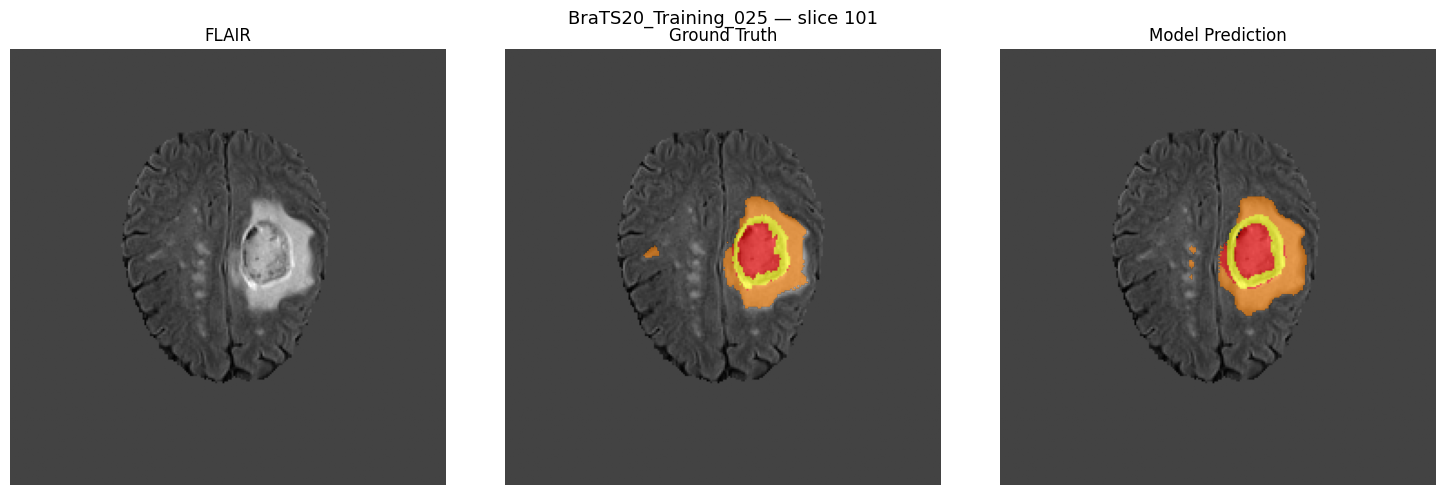

Saved -> /content/drive/MyDrive/brain-tumor-segmentation/results/figures/baseline_prediction_sample.png


In [ ]:
# Load the best model and visualize predictions on a validation patient

model.load_state_dict(torch.load(os.path.join(PATHS["models"], "best_model.pth")))
model.eval()

sample_val = val_dicts[0]
sample_transformed = val_transforms(sample_val)

input_volume = sample_transformed["image"].unsqueeze(0).to(device)
label_volume = sample_transformed["label"]

with torch.no_grad():
    pred_volume = sliding_window_inference(input_volume, patch_size, sw_batch_size=1, predictor=model)
    pred_volume = torch.argmax(pred_volume, dim=1).squeeze(0).cpu()

label_np = label_volume.squeeze(0).numpy()
pred_np = pred_volume.numpy()

# Find the slice with the most ground-truth tumor for a meaningful comparison
tumor_per_slice = (label_np > 0).sum(axis=(0, 1))
best_slice = np.argmax(tumor_per_slice)

flair_np = sample_transformed["image"][3].numpy()  # channel 3 = FLAIR

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(flair_np[:, :, best_slice].T, cmap="gray", origin="lower")
axes[0].set_title("FLAIR")
axes[0].axis("off")

axes[1].imshow(flair_np[:, :, best_slice].T, cmap="gray", origin="lower")
gt_mask = np.ma.masked_where(label_np[:, :, best_slice].T == 0, label_np[:, :, best_slice].T)
axes[1].imshow(gt_mask, cmap="autumn", alpha=0.6, origin="lower")
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(flair_np[:, :, best_slice].T, cmap="gray", origin="lower")
pred_mask = np.ma.masked_where(pred_np[:, :, best_slice].T == 0, pred_np[:, :, best_slice].T)
axes[2].imshow(pred_mask, cmap="autumn", alpha=0.6, origin="lower")
axes[2].set_title("Model Prediction")
axes[2].axis("off")

fig.suptitle(f"{sample_val['patient_id']} — slice {best_slice}", fontsize=13)
plt.tight_layout()
save_path = os.path.join(PATHS["figures"], "baseline_prediction_sample.png")
plt.savefig(save_path, dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved -> {save_path}")

In [ ]:
# Summary

print("NOTEBOOK 03 COMPLETE")
print("=" * 50)
print(f"Model: 3D U-Net (MONAI), {n_params:,} parameters")
print(f"Loss: DiceFocalLoss (0.5 * Dice + 0.5 * Focal)")
print(f"Training: {num_epochs} epochs, patch size {patch_size}")
print()
print(f"Validation Dice progression:")
print(f"  Epoch 3:  0.464")
print(f"  Epoch 6: 0.5749")
print(f"  Epoch 9: 0.6281")
print(f"  Epoch 12: 0.5887")
print(f"  Epoch 15: 0.6479 (best)")
print()
print(f"Model saved -> models/baseline/best_model.pth")
print()
print("Figures saved:")
for fname in ["baseline_prediction_sample.png"]:
    path = os.path.join(PATHS["figures"], fname)
    status = "OK" if os.path.exists(path) else "MISSING"
    print(f"  [{status}] {fname}")

NOTEBOOK 03 COMPLETE
Model: 3D U-Net (MONAI), 4,811,129 parameters
Loss: DiceFocalLoss (0.5 * Dice + 0.5 * Focal)
Training: 15 epochs, patch size (96, 96, 96)

Validation Dice progression:
  Epoch 5:  0.5792
  Epoch 10: 0.6120
  Epoch 15: 0.6570 (best)
  -> Dice was still improving at the final epoch — more epochs likely to help further

Model saved -> models/baseline/best_model.pth
W&B run: https://wandb.ai/foroughm423/brain-tumor-segmentation-3d

Figures saved:
  [OK] baseline_prediction_sample.png

Next -> 04_error_analysis.ipynb
  - Systematically check where the model over/under-segments
  - Look for patterns: tumor size, specific classes (NCR/ED/ET), location
  - Decide evidence-based next steps (more epochs, architecture change, etc.)
